In [1]:
import utils_phenom as up
import utils_signal as using
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI
out_dir = "./spectrograms_figures/"


/home/pycbc/work/Memory_Lopez/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


Chirp max strain : 2.23e-20
Memory max strain: 3.83e-23
fs_mem=200.0 Hz, nperseg_mem=200, df_mem=1.00 Hz


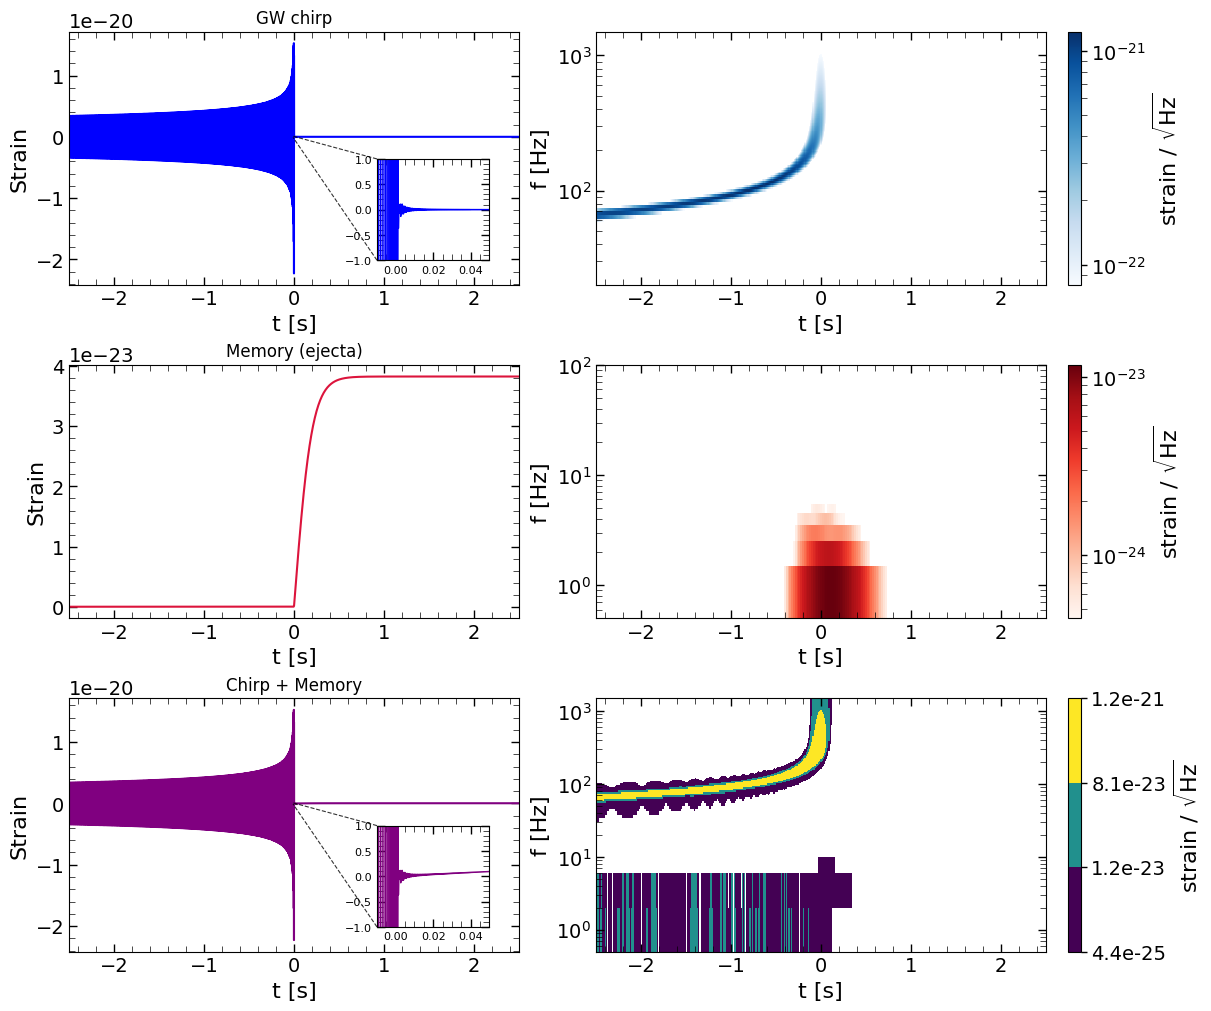

In [7]:
from scipy.signal import spectrogram as scipy_spectrogram
from matplotlib.colors import LogNorm, BoundaryNorm
import numpy as np
import matplotlib.pyplot as plt
import utils_signal as usig
import utils_phenom as up
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Chirp signal 
mtot = 5
m1 = m2 = mtot / 2
dt_chirp = 1/4096
fs_chirp = 4096
distance = 1
time_raw, raw_signal, hc = usig.get_hp_hc_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    distance=distance,
    delta_t=dt_chirp,
    f_lower=20.,
    inclination=np.pi/2
)

mask = (time_raw >= -10) & (time_raw <= 2)
time_raw = time_raw[mask]
raw_signal = raw_signal[mask]

aligned_time, aligned_signal = usig.align_signal(raw_signal, time_raw)
padded_time, padded_signal = usig.pad_signal(aligned_signal, aligned_time, r=0.5)

# Memory signal with adapted dt 
tau = 0.1          
fs_mem = 20 * 1/tau # Nyquist = 100 Hz >> f_char = 10 Hz
dt_m = 1 / fs_mem
t_start = padded_time[0]
t_end_sig = padded_time[-1]
pad_dur = 5.0       
t_mem = np.arange(t_start - pad_dur, t_end_sig + pad_dur, dt_m)

M_ej = 0.01
v_ej = 0.2
r = 1e6  # 1 Mpc
h_t = up.linear_memory_ejecta_masked(t_mem, M_ej, v_ej, tau, r, 0, model='exponential')
# Pad with last value (plateau) to avoid jump to 0
pad_samples_mem = int(pad_dur * fs_mem)
h_t_padded = np.pad(h_t, pad_samples_mem, mode='edge')
t_mem_padded = np.arange(
    t_mem[0] - pad_dur,
    t_mem[-1] + pad_dur + dt_m,
    dt_m
)[:len(h_t_padded)]

#  Resample memory onto chirp time grid for later sum 
from scipy.interpolate import interp1d
h_t_interp = interp1d(t_mem_padded, h_t_padded, bounds_error=False, fill_value=h_t_padded[-1])
memory_signal_resampled = h_t_interp(padded_time)

#  Sum signal : chirp + memory 
sum_signal = padded_signal + memory_signal_resampled

# Chirp spectrogram 
nperseg_chirp  = 1024   # df = 4096/1024 = 4 Hz
noverlap_chirp = int(0.95 * nperseg_chirp)
f_spec_c, t_spec_c, Sxx_c = scipy_spectrogram(
    padded_signal, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp,
    window='hann'
)
t_spec_c += padded_time[0]
amp_chirp = np.sqrt(Sxx_c)

#  Memory spectrogram 
nperseg_mem  = int(fs_mem * 1.0)
noverlap_mem = int(0.98 * nperseg_mem)
f_spec_m, t_spec_m, Sxx_m = scipy_spectrogram(
    h_t_padded, fs=fs_mem,
    nperseg=nperseg_mem, noverlap=noverlap_mem,
    window='hann'
)
t_spec_m += t_mem_padded[0]
amp_mem = np.sqrt(Sxx_m)

#  Sum spectrogram 
f_spec_s, t_spec_s, Sxx_s = scipy_spectrogram(
    sum_signal, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp,
    window='hann'
)
t_spec_s += padded_time[0]
amp_sum = np.sqrt(Sxx_s)

h_max_chirp = np.max(np.abs(padded_signal))
h_max_mem   = np.max(np.abs(h_t))
print(f"Chirp max strain : {h_max_chirp:.2e}")
print(f"Memory max strain: {h_max_mem:.2e}")
print(f"fs_mem={fs_mem} Hz, nperseg_mem={nperseg_mem}, df_mem={fs_mem/nperseg_mem:.2f} Hz")

#  Normalisations 
vmin_c, vmax_c = np.percentile(amp_chirp[amp_chirp > 0], [99., 100])
vmin_m, vmax_m = np.percentile(amp_mem[amp_mem > 0],     [99., 100])

norm_chirp = LogNorm(vmin=vmin_c, vmax=vmax_c)
norm_mem   = LogNorm(vmin=vmin_m, vmax=vmax_m)

# Colorbar disjointe pour le dernier spectrogramme (sum)
# On force une coupure entre les deux intervalles

bounds = [vmin_m, vmax_m, vmin_c, vmax_c]
norm_disjoint = BoundaryNorm(bounds, ncolors=256, extend='neither')

#  Plot : 3 rows (chirp / memory / sum), 2 columns (time / spectrogram) 
signals = [
    (padded_time, padded_signal, amp_chirp, t_spec_c, f_spec_c, "GW chirp","blue","Blues",norm_chirp, vmin_c),
    (padded_time, memory_signal_resampled, amp_mem,   t_spec_m, f_spec_m, "Memory (ejecta)", "crimson", "Reds",norm_mem,vmin_m),
    (padded_time, sum_signal, amp_sum, t_spec_s, f_spec_s, "Chirp + Memory","purple", "viridis", norm_disjoint, vmin_m),
]

fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

for i, (t_sig, sig_t, amp_spec, t_spec, f_spec, title, color, cmap, norm, vmin) in enumerate(signals):
    # Time domain
    axs[i, 0].plot(t_sig, sig_t, color=color, lw=1.5)
    axs[i, 0].set_title(title)
    axs[i, 0].set_xlabel("t [s]")
    axs[i, 0].set_ylabel("Strain")
    axs[i, 0].set_xlim(-2.5, 2.5)
    axs[i, 0].grid(False)

    # Spectrogram
    amp_masked = np.ma.masked_less_equal(amp_spec, vmin * 1.005)
    pcm = axs[i, 1].pcolormesh(
        t_spec, f_spec, amp_masked,
        shading='auto', cmap=cmap, norm=norm
    )
    axs[i, 1].set_yscale('log')
    if i == 1:
        axs[i, 1].set_ylim(0.5, 100)
    else:
        axs[i, 1].set_ylim(20, 1500)
    axs[i, 1].set_xlim(-2.5, 2.5)
    axs[i, 1].set_xlabel("t [s]")
    axs[i, 1].set_ylabel("f [Hz]")
    axs[i, 1].grid(False)

    # Colorbar personnalisée pour la dernière ligne
    if i == 2:
        axs[i,1].set_ylim(0.5, 1500)
        cb = fig.colorbar(
            pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$',
            boundaries=bounds, ticks=[vmin_m, vmax_m, vmin_c, vmax_c]
        )
        cb.ax.set_yticklabels([f"{vmin_m:.1e}", f"{vmax_m:.1e}", f"{vmin_c:.1e}", f"{vmax_c:.1e}"])
    else:
        cb = fig.colorbar(pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$')
    cb.ax.tick_params(which='both', direction='out', length=4)
  
    if i in [0, 2]:
        ax_ins = inset_axes(
            axs[i, 0],
            width="25%", height="40%",
            loc='lower right',
            bbox_to_anchor=(-0.05, 0.07, 1, 1),
            bbox_transform=axs[i, 0].transAxes
        )
        # Plot the time-domain signal in the inset 
        ax_ins.plot(t_sig, sig_t, color=color, lw=1.0)
        ax_ins.set_xlim(-0.01, 0.05)   # zoom around merger
        mask_zoom = (t_sig >= -0.01) & (t_sig <= 0.05)
        if mask_zoom.any():
            ax_ins.set_ylim(-0.01*1e-20, 0.01*1e-20)
        ax_ins.tick_params(axis='both', which='major', labelsize=8,
                           direction='in', top=True, right=True)
        ax_ins.yaxis.offsetText.set_visible(False)
        ax_ins.grid(False)
        
        mark_inset(axs[i, 0], ax_ins, loc1=2, loc2=3,
                   fc="none", ec="black", lw=0.8, linestyle="--", alpha=0.8)

#plt.savefig(out_dir + "spectrogram_chirp_memory_stft_rows.png", dpi=150)
plt.show()

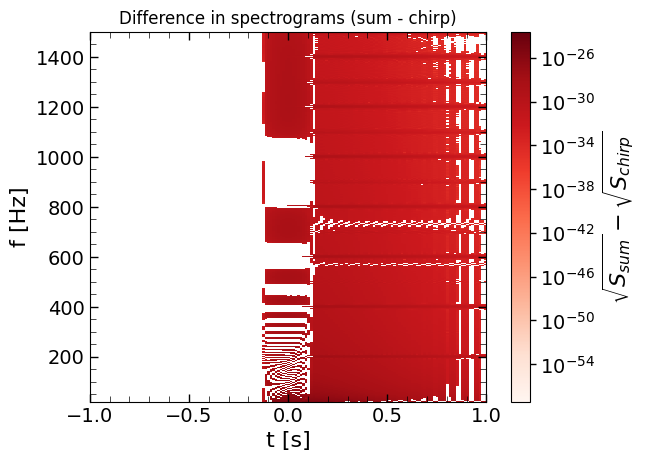

In [17]:
amp_diff = amp_sum - amp_chirp
plt.pcolormesh(t_spec_s, f_spec_s, amp_diff, cmap='Reds', norm=LogNorm())
cb = plt.colorbar(label=r'$\sqrt{S_{sum}} - \sqrt{S_{chirp}}$')
cb.ax.tick_params(which='both', direction='out', length=4)

plt.ylim(20, 1500)
plt.xlim(-1, 1)
plt.xlabel('t [s]')
plt.ylabel('f [Hz]')
plt.title('Difference in spectrograms (sum - chirp)')
plt.grid(False)
plt.show()

Chirp max strain : 2.23e-20
Memory max strain: 3.83e-23
fs_mem=200.0 Hz, nperseg_mem=200, df_mem=1.00 Hz


/tmp/ipykernel_31107/1331144732.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels([f"{vmin_m:.1e}", f"{vmax_m:.1e}", f"{vmin_c:.1e}", f"{vmax_c:.1e}"])


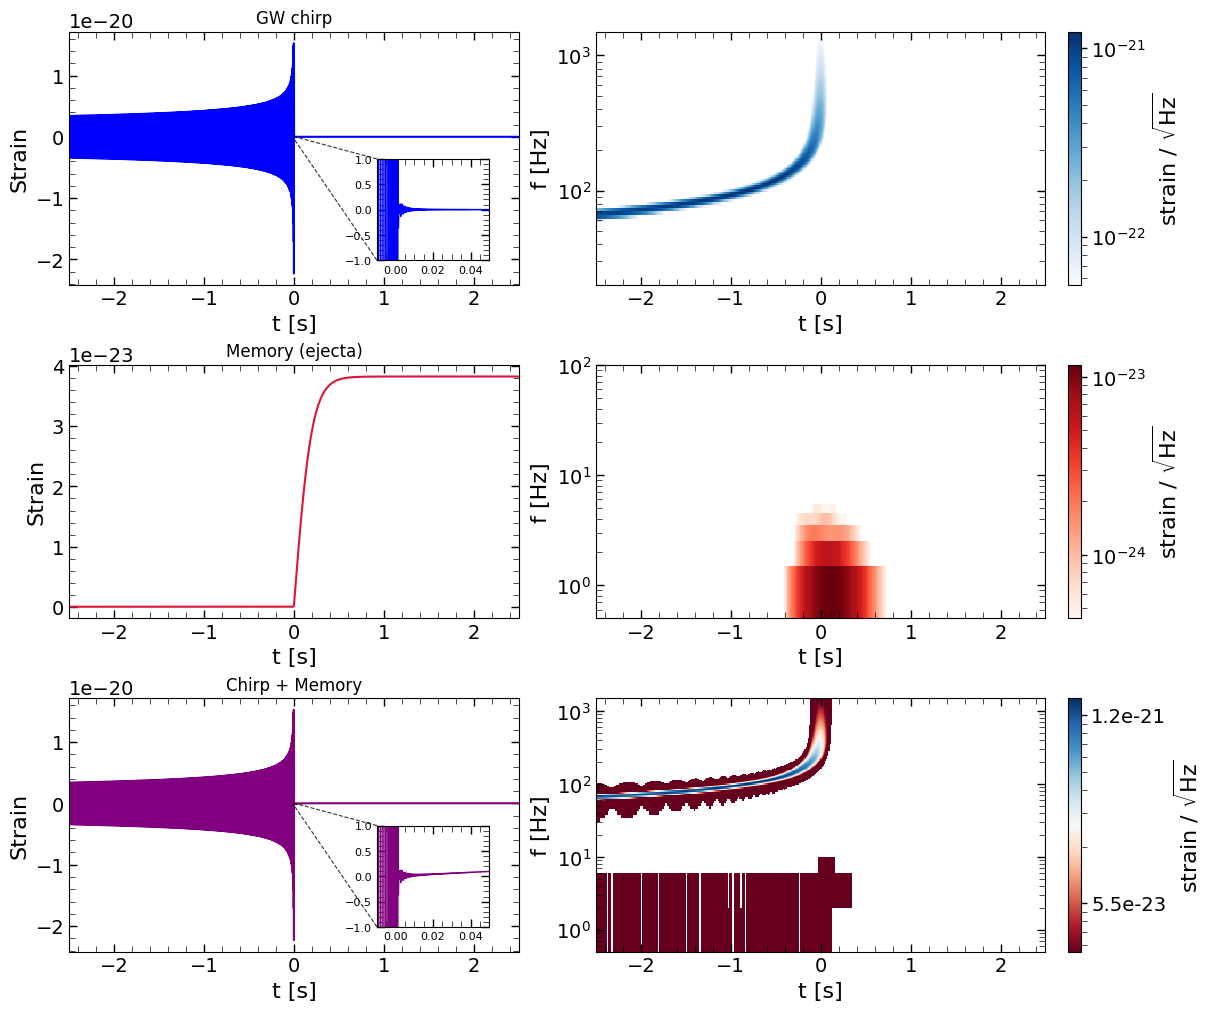

In [5]:
from scipy.signal import spectrogram as scipy_spectrogram
from matplotlib.colors import LogNorm, BoundaryNorm
import numpy as np
import matplotlib.pyplot as plt
import utils_signal as usig
import utils_phenom as up
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Chirp signal 
mtot = 5
m1 = m2 = mtot / 2
dt_chirp = 1/4096
fs_chirp = 4096
distance = 1
time_raw, raw_signal, hc = usig.get_hp_hc_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    distance=distance,
    delta_t=dt_chirp,
    f_lower=20.,
    inclination=np.pi/2
)
mask = (time_raw >= -10) & (time_raw <= 10)
time_raw = time_raw[mask]
raw_signal = raw_signal[mask]

aligned_time, aligned_signal = usig.align_signal(raw_signal, time_raw)
padded_time, padded_signal = usig.pad_signal(aligned_signal, aligned_time, r=0.5)

# Memory signal with adapted dt 
tau = 0.1          
fs_mem = 20 * 1/tau # Nyquist = 100 Hz >> f_char = 10 Hz
dt_m = 1 / fs_mem
t_start = padded_time[0]
t_end_sig = padded_time[-1]
pad_dur = 2.0       
t_mem = np.arange(t_start - pad_dur, t_end_sig + pad_dur, dt_m)

M_ej = 0.01
v_ej = 0.2
r = 1e6  # 1 Mpc
h_t = up.linear_memory_ejecta_masked(t_mem, M_ej, v_ej, tau, r, -np.log(3)*1e-3, model='exponential')
# Pad with last value (plateau) to avoid jump to 0
pad_samples_mem = int(pad_dur * fs_mem)
h_t_padded = np.pad(h_t, pad_samples_mem, mode='edge')
t_mem_padded = np.arange(
    t_mem[0] - pad_dur,
    t_mem[-1] + pad_dur + dt_m,
    dt_m
)[:len(h_t_padded)]

#  Resample memory onto chirp time grid for later sum 
from scipy.interpolate import interp1d
h_t_interp = interp1d(t_mem_padded, h_t_padded, bounds_error=False, fill_value=h_t_padded[-1])
memory_signal_resampled = h_t_interp(padded_time)

#  Sum signal : chirp + memory 
sum_signal = padded_signal + memory_signal_resampled

# Chirp spectrogram 
nperseg_chirp  = 1024   # df = 4096/1024 = 4 Hz
noverlap_chirp = int(0.95 * nperseg_chirp)
f_spec_c, t_spec_c, Sxx_c = scipy_spectrogram(
    padded_signal, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp,
    window='hann'
)
t_spec_c += padded_time[0]
amp_chirp = np.sqrt(Sxx_c)

#  Memory spectrogram 
nperseg_mem  = int(fs_mem * 1.0)
noverlap_mem = int(0.98 * nperseg_mem)
f_spec_m, t_spec_m, Sxx_m = scipy_spectrogram(
    h_t_padded, fs=fs_mem,
    nperseg=nperseg_mem, noverlap=noverlap_mem,
    window='hann'
)
t_spec_m += t_mem_padded[0]
amp_mem = np.sqrt(Sxx_m)

#  Sum spectrogram 
f_spec_s, t_spec_s, Sxx_s = scipy_spectrogram(
    sum_signal, fs=fs_chirp,
    nperseg=nperseg_chirp, noverlap=noverlap_chirp,
    window='hann'
)
t_spec_s += padded_time[0]
amp_sum = np.sqrt(Sxx_s)

h_max_chirp = np.max(np.abs(padded_signal))
h_max_mem   = np.max(np.abs(h_t))
print(f"Chirp max strain : {h_max_chirp:.2e}")
print(f"Memory max strain: {h_max_mem:.2e}")
print(f"fs_mem={fs_mem} Hz, nperseg_mem={nperseg_mem}, df_mem={fs_mem/nperseg_mem:.2f} Hz")

#  Normalisations 
vmin_c, vmax_c = np.percentile(amp_chirp[amp_chirp > 0], [99., 100])
vmin_m, vmax_m = np.percentile(amp_mem[amp_mem > 0],     [99., 100])

norm_chirp = LogNorm(vmin=vmin_c, vmax=vmax_c)
norm_mem   = LogNorm(vmin=vmin_m, vmax=vmax_m)

# Colorbar disjointe pour le dernier spectrogramme (sum)
# On force une coupure entre les deux intervalles


#  Plot : 3 rows (chirp / memory / sum), 2 columns (time / spectrogram) 
signals = [
    (padded_time, padded_signal, amp_chirp, t_spec_c, f_spec_c, "GW chirp","blue","Blues",norm_chirp, vmin_c),
    (padded_time, memory_signal_resampled, amp_mem,   t_spec_m, f_spec_m, "Memory (ejecta)", "crimson", "Reds",norm_mem,vmin_m),
    (padded_time, sum_signal, amp_sum, t_spec_s, f_spec_s, "Chirp + Memory","purple", "RdBu", norm_chirp, vmin_m),
]

fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

for i, (t_sig, sig_t, amp_spec, t_spec, f_spec, title, color, cmap, norm, vmin) in enumerate(signals):
    # Time domain
    axs[i, 0].plot(t_sig, sig_t, color=color, lw=1.5)
    axs[i, 0].set_title(title)
    axs[i, 0].set_xlabel("t [s]")
    axs[i, 0].set_ylabel("Strain")
    axs[i, 0].set_xlim(-2.5, 2.5)
    axs[i, 0].grid(False)

    # Spectrogram
    amp_masked = np.ma.masked_less_equal(amp_spec, vmin * 1.005)
    pcm = axs[i, 1].pcolormesh(
        t_spec, f_spec, amp_masked,
        shading='auto', cmap=cmap, norm=norm
    )
    axs[i, 1].set_yscale('log')
    if i == 1:
        axs[i, 1].set_ylim(0.5, 100)
    else:
        axs[i, 1].set_ylim(20, 1500)
    axs[i, 1].set_xlim(-2.5, 2.5)
    axs[i, 1].set_xlabel("t [s]")
    axs[i, 1].set_ylabel("f [Hz]")
    axs[i, 1].grid(False)

    # Colorbar personnalisée pour la dernière ligne
    if i == 2:
        axs[i,1].set_ylim(0.5, 1500)
        cb = fig.colorbar(pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$')
        cb.ax.set_yticklabels([f"{vmin_m:.1e}", f"{vmax_m:.1e}", f"{vmin_c:.1e}", f"{vmax_c:.1e}"])
    else:
        cb = fig.colorbar(pcm, ax=axs[i, 1], label=r'strain / $\sqrt{\mathrm{Hz}}$')
    cb.ax.tick_params(which='both', direction='out', length=4)
  
    if i in [0, 2]:
        ax_ins = inset_axes(
            axs[i, 0],
            width="25%", height="40%",
            loc='lower right',
            bbox_to_anchor=(-0.05, 0.07, 1, 1),
            bbox_transform=axs[i, 0].transAxes
        )
        # Plot the time-domain signal in the inset 
        ax_ins.plot(t_sig, sig_t, color=color, lw=1.0)
        ax_ins.set_xlim(-0.01, 0.05)   # zoom around merger
        mask_zoom = (t_sig >= -0.01) & (t_sig <= 0.05)
        if mask_zoom.any():
            ax_ins.set_ylim(-0.01*1e-20, 0.01*1e-20)
        ax_ins.tick_params(axis='both', which='major', labelsize=8,
                           direction='in', top=True, right=True)
        ax_ins.yaxis.offsetText.set_visible(False)
        ax_ins.grid(False)
        
        mark_inset(axs[i, 0], ax_ins, loc1=2, loc2=3,
                   fc="none", ec="black", lw=0.8, linestyle="--", alpha=0.8)

plt.show()

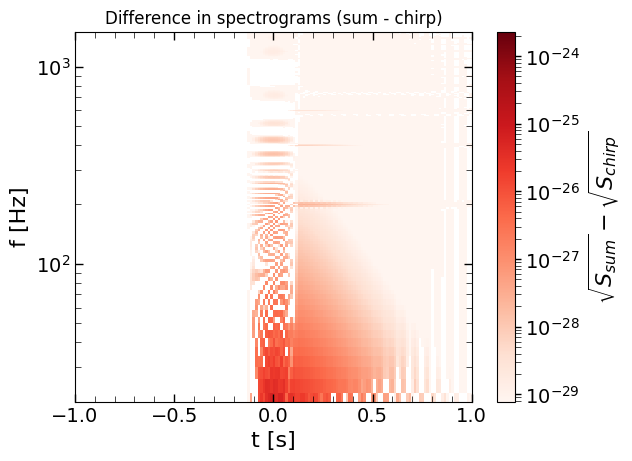

In [8]:
amp_diff = amp_sum - amp_chirp
plt.pcolormesh(t_spec_s, f_spec_s, amp_diff, shading='auto', cmap='Reds', norm=LogNorm(vmin=np.percentile(amp_diff[amp_diff > 0], 99), vmax=np.max(amp_diff)))
cb = plt.colorbar(label=r'$\sqrt{S_{sum}} - \sqrt{S_{chirp}}$')
cb.ax.tick_params(which='both', direction='out', length=4)

plt.ylim(20, 1500)
plt.xlim(-1, 1)
plt.xlabel('t [s]')
plt.ylabel('f [Hz]')
plt.yscale('log')

plt.title('Difference in spectrograms (sum - chirp)')
plt.grid(False)
plt.show()